# Get started with gym-invmgmt

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/r2barati/gym-invmgmt/blob/main/notebooks/01_get_started.ipynb)

This notebook runs on a CPU in about five minutes. No GPU, checkpoints, or solvers are needed.

1. **Run the environment** from the PyPI package.
2. **Write a policy** and compare it with random ordering on one scenario.
3. **Benchmark it** against the published baselines from the paper
   ([arXiv:2605.11355](https://arxiv.org/abs/2605.11355)) on the same 22 scenarios and 10 seeds.

In [1]:
%pip install -q gym-invmgmt==0.2.1 pandas

Note: you may need to restart the kernel to use updated packages.


## 1. Run the environment

`GymInvMgmt/MultiEchelon-v0` is a divergent supply chain: raw-material suppliers feed three factories,
which supply two distributors, which supply one retailer facing customer demand. Each period you choose
an order quantity for every reorder link (the action), and the reward is that period's profit.
Demand here has a trend and a seasonal cycle, as in the benchmark's core scenarios.

In [2]:
import importlib
from types import SimpleNamespace

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import gym_invmgmt
from gym_invmgmt import compute_kpis

# Trend + seasonal demand around a mean of 20 units per period
DEMAND = {"type": "combined_chaos", "effects": ["trend", "seasonal"], "base_mu": 20, "use_goodwill": False}


def make_env():
    return gym.make("GymInvMgmt/MultiEchelon-v0", demand_config=DEMAND, num_periods=30)


env = make_env()
net = env.unwrapped.network
distributors = [n for n in net.distrib if n not in net.retail]  # net.distrib also lists the retailer
print("gym-invmgmt", gym_invmgmt.__version__)
print("observation:", env.observation_space.shape, "| action:", env.action_space.shape)
print("retailer:", net.retail, "| distributors:", distributors, "| factories:", net.factory,
      "| raw materials:", net.rawmat)
print("reorder links (supplier, buyer):", net.reorder_links)

gym-invmgmt 0.2.1
observation: (71,) | action: (11,)
retailer: [1] | distributors: [2, 3] | factories: [4, 5, 6] | raw materials: [7, 8]
reorder links (supplier, buyer): [(2, 1), (3, 1), (4, 2), (4, 3), (5, 2), (6, 2), (6, 3), (7, 4), (7, 5), (8, 5), (8, 6)]


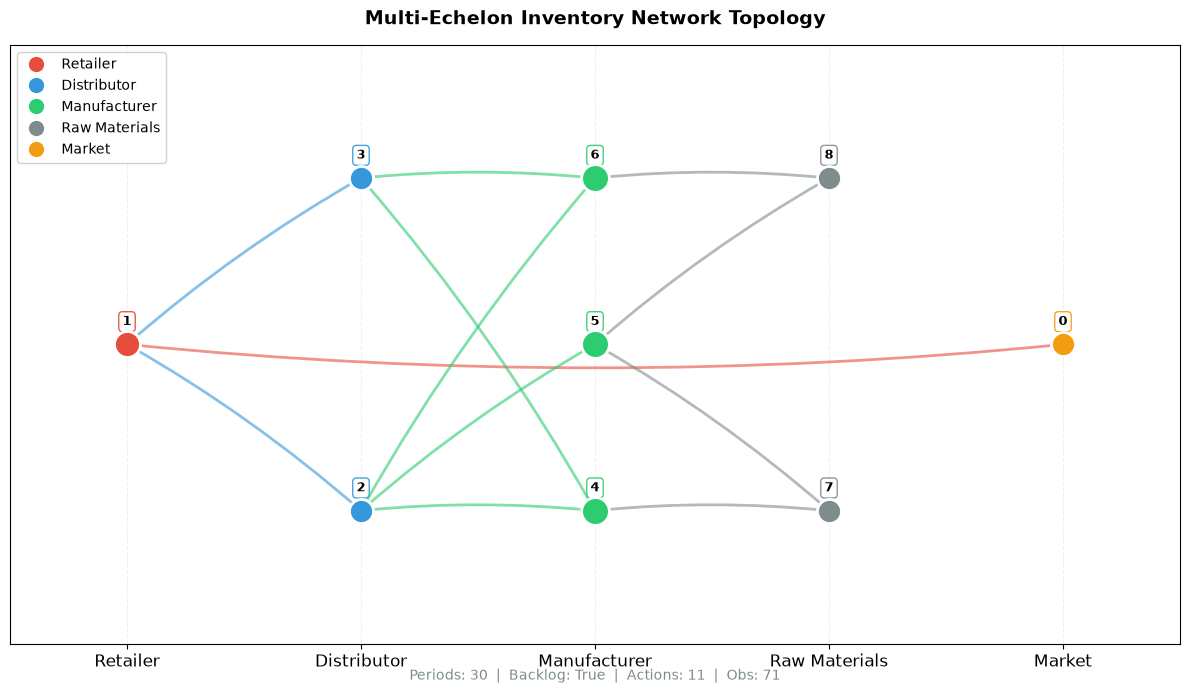

In [3]:
_ = env.unwrapped.plot_network()

The observation is a flat vector laid out as `[demand | backlog | inventory | pipeline | (t, goodwill)]`:
last period's demand and unmet demand for each retail link, on-hand inventory at each stocking node,
units in transit on each reorder link, then the period index and customer goodwill.

`make_view` describes that layout together with the static network. It provides the same fields the
benchmark gives a *blind* agent in Part 3, so a policy written against it runs there unchanged.

In [4]:
def make_view(env):
    """Stand-in for the benchmark's blind AgentView, built from a PyPI environment."""
    core = env.unwrapped
    net = core.network
    n_retail, n_main = len(net.retail_links), len(net.main_nodes)
    obs_slices = {
        "demand": slice(0, n_retail),
        "backlog": slice(n_retail, 2 * n_retail),
        "inventory": slice(2 * n_retail, 2 * n_retail + n_main),
    }
    pipeline_slices, i = {}, obs_slices["inventory"].stop
    for link in net.reorder_links:
        lead_time = net.lead_times[link]
        if lead_time > 0:
            pipeline_slices[link] = slice(i, i + lead_time)
            i += lead_time
    return SimpleNamespace(
        observation_space=env.observation_space,
        action_space=env.action_space,
        num_periods=core.num_periods,
        graph=core.graph,
        network=net,
        obs_slices=obs_slices,
        pipeline_slices=pipeline_slices,
        demand_history=lambda: core.D[:core.period].copy(),  # realized demand, past periods only
    )

## 2. Write a policy

A policy is a class with `__init__(self, view, seed)` and `get_action(self, obs, t)`, which returns one
order quantity per reorder link. The one below is an order-up-to (base-stock) policy: it forecasts demand
as a moving average of past retail demand, passes that forecast upstream, and orders the gap between a
target and each node's inventory position. It uses only blind information.

**Replace it with your own algorithm.** The rest of the notebook runs whatever `my_agent.py` contains.

In [5]:
%%writefile my_agent.py
import networkx as nx
import numpy as np


class MyAgent:
    def __init__(self, view, seed, window=5, z=1.0):
        self.view = view
        self.window = window  # periods in the demand moving average
        self.z = z            # safety-stock factor
        net, g = view.network, view.graph
        self.n_retail = len(net.retail_links)

        # Reorder links feeding each stocking node: (action index, link)
        self.incoming = {}
        for idx, link in enumerate(net.reorder_links):
            self.incoming.setdefault(link[1], []).append((idx, link))

        # share[node] @ retail_demand = demand flowing through node.
        # Each node passes its demand to its suppliers in equal parts.
        share = {n: np.zeros(self.n_retail) for n in net.main_nodes}
        for i, (retailer, _) in enumerate(net.retail_links):
            share[retailer][i] = 1.0
        for node in reversed(list(nx.topological_sort(g))):
            if node not in share or node not in self.incoming:
                continue
            suppliers = [src for _, (src, _) in self.incoming[node] if src in share]
            for src in suppliers:
                share[src] += share[node] / len(suppliers)
        self.share = share

        self.lead_time = {n: max(g.edges[link]["L"] for _, link in links)
                          for n, links in self.incoming.items()}
        self.backlog_idx = {n: [i for i, (r, _) in enumerate(net.retail_links) if r == n]
                            for n in net.main_nodes}

        # Demand guess before any demand is observed: initial retail stock spread over the longest lead time
        retail_i0 = np.mean([g.nodes[r].get("I0", 0) for r in net.retail])
        self.prior = retail_i0 / (max(self.lead_time.values()) + 1) or 20.0

    def get_action(self, obs, t):
        view = self.view
        history = view.demand_history()
        mu = history[-self.window:].mean(axis=0) if len(history) else np.full(self.n_retail, self.prior)

        on_hand = obs[view.obs_slices["inventory"]]
        backlog = obs[view.obs_slices["backlog"]]
        actions = np.zeros(view.action_space.shape)
        for pos, node in enumerate(view.network.main_nodes):
            links = self.incoming.get(node)
            if not links:
                continue
            demand = float(self.share[node] @ mu) * (self.lead_time[node] + 1)
            target = demand + self.z * np.sqrt(max(demand, 0.0))
            in_transit = sum(obs[view.pipeline_slices[link]].sum()
                             for _, link in links if link in view.pipeline_slices)
            position = on_hand[pos] + in_transit - backlog[self.backlog_idx[node]].sum()
            order = max(0.0, target - position)
            for idx, _ in links:
                actions[idx] = order / len(links)
        return np.clip(actions, view.action_space.low, view.action_space.high)

Writing my_agent.py


In [6]:
import my_agent

importlib.reload(my_agent)  # picks up edits to my_agent.py
MyAgent = my_agent.MyAgent


class RandomAgent:
    def __init__(self, view, seed):
        self.space = view.action_space
        self.space.seed(seed)

    def get_action(self, obs, t):
        return self.space.sample()


def rollout(agent_cls, seed):
    """Run one 30-period episode and return the finished environment."""
    env = make_env()
    agent = agent_cls(make_view(env), seed)
    obs, _ = env.reset(seed=seed)
    done, t = False, 0
    while not done:
        obs, reward, terminated, truncated, _ = env.step(agent.get_action(obs, t))
        done, t = terminated or truncated, t + 1
    return env.unwrapped


rows = [{"policy": name, "seed": seed, **compute_kpis(rollout(cls, seed))}
        for name, cls in [("Random", RandomAgent), ("MyAgent", MyAgent)]
        for seed in range(10)]
results = pd.DataFrame(rows)
results.groupby("policy")[["total_profit", "fill_rate", "avg_inventory"]].agg(["mean", "std"]).round(2)

total_profit          fill_rate       avg_inventory        
                mean      std      mean   std          mean     std
policy                                                             
MyAgent      1316.27    79.66      0.97  0.02         91.58    4.38
Random     -54356.19  2785.94      1.00  0.00      14968.56  767.42

Random ordering floods the chain with stock and loses money; the base-stock policy keeps a high
fill rate with far less inventory. The chart shows one reason multi-echelon control is hard: orders swing
more the further upstream they are placed (the bullwhip effect).

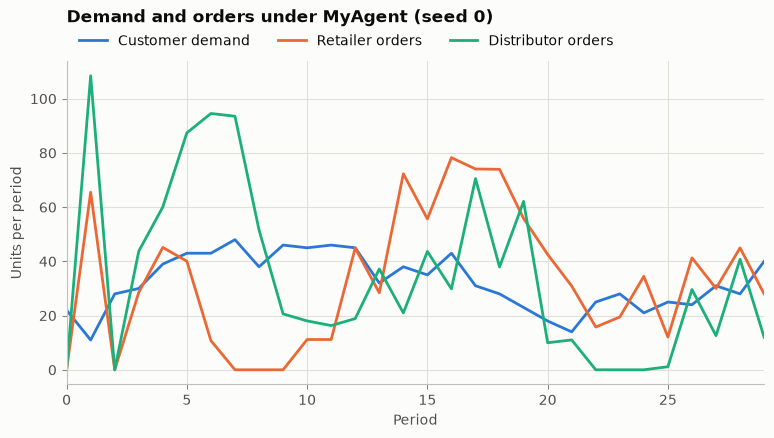

Customer demand     mean   32.3   std   10.1
Retailer orders     mean   33.2   std   24.2
Distributor orders  mean   34.4   std   31.1


In [7]:
# Chart styling: light surface, recessive axes, one color per series
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.titlelocation": "left", "axes.titlesize": 12, "axes.titleweight": "bold", "font.size": 10,
})

core = rollout(MyAgent, seed=0)
T = core.period
link_idx = {link: i for i, link in enumerate(net.reorder_links)}


def orders_into(nodes):
    """Units ordered each period on all reorder links whose buyer is in `nodes`."""
    return core.R[:T, [link_idx[link] for link in net.reorder_links if link[1] in nodes]].sum(axis=1)


series = {
    "Customer demand": core.D[:T].sum(axis=1),
    "Retailer orders": orders_into(net.retail),
    "Distributor orders": orders_into(distributors),
}

fig, ax = plt.subplots(figsize=(9, 4.2))
for (label, y), color in zip(series.items(), SERIES):
    ax.plot(np.arange(T), y, color=color, linewidth=2, label=label)
ax.set(xlabel="Period", ylabel="Units per period", xlim=(0, T - 1))
ax.set_title("Demand and orders under MyAgent (seed 0)", pad=28)
ax.legend(frameon=False, ncol=3, loc="lower left", bbox_to_anchor=(0, 1.0))
plt.show()

for label, y in series.items():
    print(f"{label:<19} mean {y.mean():6.1f}   std {y.std():6.1f}")

## 3. Benchmark your policy against the paper

The companion repository [gym-invmgmt-paper](https://github.com/r2barati/gym-invmgmt-paper) stores the
published per-seed results of every baseline in the paper. Its `evaluate_custom.py` runs your class on the
paper's 22 core scenarios (two networks; trend + seasonal, shock, stationary, and real M5 demand; with and
without goodwill and backlog) across 10 seeds, then pairs each episode with the baselines' results for the
same scenario and seed. Only your agent runs, so this takes well under a minute.

`--tier` declares what your agent uses: `blind` (observations, network, and past demand, as above) or
`informed`, which also exposes `view.demand_mean(t)`, the true expected demand. Compare against baselines
of the same tier. The benchmark uses the paper repository's bundled copy of the environment, whose
dynamics are identical to the PyPI package.

In [8]:
PAPER_COMMIT = "f6c8a25b7c7e9fd7373879d0cd8a2049e97a257a"  # gym-invmgmt-paper commit with evaluate_custom.py
!test -d gym-invmgmt-paper || (git init -q gym-invmgmt-paper && git -C gym-invmgmt-paper fetch -q --depth 1 https://github.com/r2barati/gym-invmgmt-paper {PAPER_COMMIT} && git -C gym-invmgmt-paper checkout -q FETCH_HEAD)

In [9]:
import sys  # noqa: F401 -- used by the shell command below

!{sys.executable} gym-invmgmt-paper/benchmarks/evaluate_custom.py --policy my_agent.py:MyAgent --tier blind --out-dir results/MyAgent


Evaluating MyAgent (blind) on 22 scenarios x 10 seeds


  [ 1/22] A_Core|base|trend+seasonal|GW:False|BL:True|MARL:False         mean profit    1257.4


  [ 2/22] A_Core|base|trend+seasonal|GW:False|BL:False|MARL:False        mean profit     919.8


  [ 3/22] A_Core|base|trend+seasonal|GW:True|BL:True|MARL:False          mean profit     515.3


  [ 4/22] A_Core|base|trend+seasonal|GW:True|BL:False|MARL:False         mean profit     507.3


...

  [20/22] B_PaperReplication|serial|stationary|GW:False|BL:False|MARL:False mean profit     804.7


  [21/22] D_WalmartM5|base|M5_volatile|GW:False|BL:True|MARL:False       mean profit    -103.6


  [22/22] D_WalmartM5|serial|M5_volatile|GW:False|BL:True|MARL:False     mean profit       6.6



Summary (paired on matched scenario x seed; Oracle is a perfect-information upper bound, not a deployable method):



          Agent        Tier  Scenarios  MeanProfit  MeanFillRate  MeanOptGap_Pct  CustomMinusBaseline Wins Ties Losses  Wilcoxon_p
         Oracle upper bound         22   1,391.263         0.949           0.000             -653.291    0    0     22       0.000
         MSSP-I    informed         22   1,321.685         0.943           5.110             -583.713    0    0     22       0.000
PPO-Transformer    informed         22   1,062.306         0.892          25.486             -324.334    4    3     15       0.001
       Residual    informed         22     994.981         0.882          26.829             -257.009    1    4     17       0.000
EchelonApprox-I    informed         22     982.514         0.917          27.586             -244.542    2    4     16       0.000
        (s,S)-I    informed         22     977.970         0.912          28.915             -239.998    4    3     15       0.001
   Newsvendor-I    informed         22     951.409         0.875          29.741   

MyAgent ranks 11 of 14 blind agents by mean optimality gap.



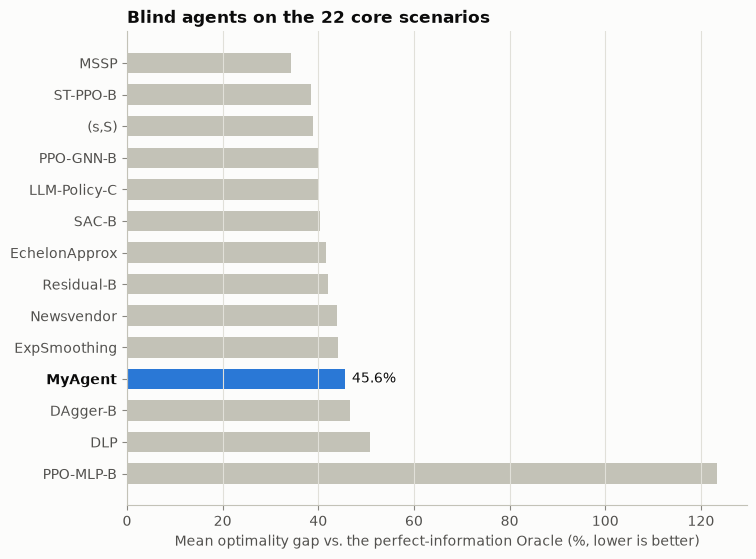

,Agent,MeanProfit,MeanFillRate,MeanOptGap_Pct,MyAgent wins,ties,losses
0,MSSP,917.927,0.822,34.332,1,8,13
1,ST-PPO-B,847.030,0.794,38.502,8,5,9
2,"(s,S)",862.759,0.859,38.920,4,5,13
3,PPO-GNN-B,813.968,0.729,39.860,12,1,9
4,LLM-Policy-C,854.550,0.902,40.211,7,2,13
5,SAC-B,824.580,0.796,40.263,10,3,9
6,EchelonApprox,843.777,0.834,41.634,9,4,9
7,Residual-B,803.618,0.804,42.004,4,5,13
8,Newsvendor,783.353,0.812,43.810,5,8,9
9,ExpSmoothing,782.636,0.820,44.208,6,8,8


In [10]:
summary = pd.read_csv("results/MyAgent/summary.csv")
# Blind agents evaluated on all 22 scenarios, best (lowest optimality gap) first
blind = summary[(summary.Tier == "blind") & (summary.Scenarios == 22)].sort_values("MeanOptGap_Pct")
rank = blind.Agent.tolist().index("MyAgent") + 1
print(f"MyAgent ranks {rank} of {len(blind)} blind agents by mean optimality gap.\n")

fig, ax = plt.subplots(figsize=(8, 0.34 * len(blind) + 1.4))
colors = [SERIES[0] if a == "MyAgent" else AXIS for a in blind.Agent]
ax.barh(blind.Agent, blind.MeanOptGap_Pct, color=colors, height=0.65)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.annotate(f"{blind.MeanOptGap_Pct.iloc[rank - 1]:.1f}%", (blind.MeanOptGap_Pct.iloc[rank - 1], rank - 1),
            xytext=(5, 0), textcoords="offset points", va="center", color=INK)
for tick in ax.get_yticklabels():
    if tick.get_text() == "MyAgent":
        tick.set_color(INK)
        tick.set_fontweight("bold")
ax.set(xlabel="Mean optimality gap vs. the perfect-information Oracle (%, lower is better)",
       title="Blind agents on the 22 core scenarios")
plt.show()

table = blind[["Agent", "MeanProfit", "MeanFillRate", "MeanOptGap_Pct", "Wins", "Ties", "Losses"]].round(3)
for col in ("Wins", "Ties", "Losses"):  # MyAgent's own row has no comparison
    table[col] = table[col].map(lambda v: "–" if pd.isna(v) else int(v))
table.rename(columns={"Wins": "MyAgent wins", "Ties": "ties", "Losses": "losses"}).reset_index(drop=True)

*MyAgent wins / ties / losses* count scenarios where the 95% confidence interval of MyAgent's profit
minus that baseline's, over the 10 paired seeds, lies above, overlaps, or lies below zero.

## Next steps

- Edit `my_agent.py` (or the cell that writes it) and rerun from Part 2.
- If your agent uses `view.demand_mean(t)`, run the benchmark with `--tier informed` and compare against the
  informed baselines.
- `results/MyAgent/` holds per-episode KPIs (`episodes.csv`), paired differences with 95% CIs for every
  baseline and scenario (`comparison.csv`), the summary above (`summary.csv`), and `run_info.json` with your
  policy file's hash, the seeds, and package versions.
- `--blocks`, `--seeds`, and `--baselines` narrow a run; see
  `python gym-invmgmt-paper/benchmarks/evaluate_custom.py --help`.

If you use gym-invmgmt in your research, please cite:

```bibtex
@misc{barati2026gyminvmgmt,
  title = {gym-invmgmt: An Open Benchmarking Framework for Inventory Management Methods},
  author = {Barati, Reza and Hu, Qinmin Vivian},
  year = {2026},
  eprint = {2605.11355},
  archivePrefix = {arXiv},
  primaryClass = {cs.LG},
  url = {https://arxiv.org/abs/2605.11355}
}
```